Uma barra de massa $M$ e cuja posição do centro é $x$ pode se mover sobre um apoio sujeita a um atrito. Em uma ceta posição $x_1$ há um pêndulo de comprimento $l$ e massa $m$ deslocado de um ângulo $\theta_1$. Mais a frente em uma posição $x_2$ há outro pêndulo de comprimento $l$ e massa $m$ deslocado de um ângulo $\theta_2$. Isso ocorre sucessivamente até a posição $x_n$, onde o N-ésimo pêndulo está acoplado. (n = 2, 3, ..., N).

$\ddot x = \dot v$ ; $\ddot \theta_n = \dot \omega_n$

$\dot x = v$ ; $\dot \theta_n = \omega_n$

Equação da barra: $\dot v = \frac{1}{M + nm - m(\sum_{n=2}^{N} \cos^2 \theta_n)} [- \mu v - mg(\sum_{n=2}^{N} \sin \theta_n \cos \theta_n) - ml(\sum_{n=2}^{N} \cos^2 \theta_n)]$

Equação dos pêndulos: $\dot \omega_n = \frac{1}{l} \dot v \cos \theta_n - g \sin \theta_n$



In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

Pêndulo   1: θ = -0.1511 rad
Pêndulo  26: θ = -0.1194 rad
Pêndulo  51: θ = -0.1448 rad
Pêndulo  76: θ = 0.1905 rad
Pêndulo 100: θ = 0.0650 rad
posição final da barra: 0.00013843519689180043
velocidade final da barra: 0.004046770703866695


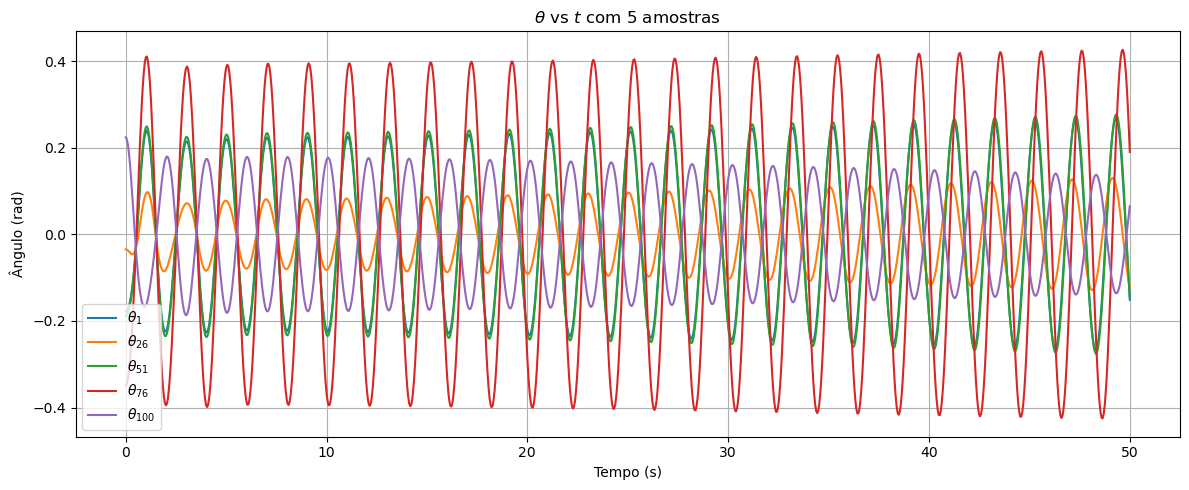

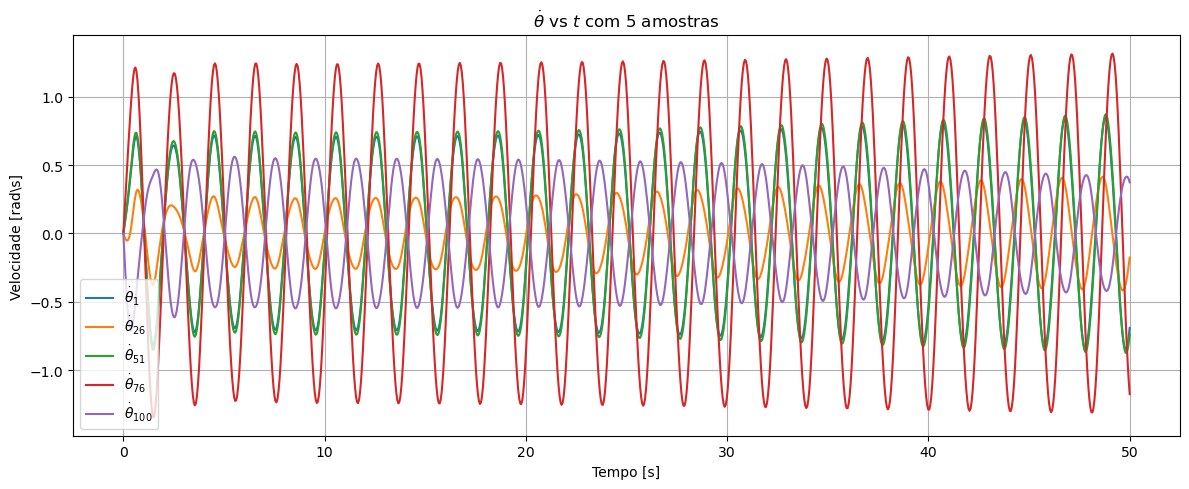

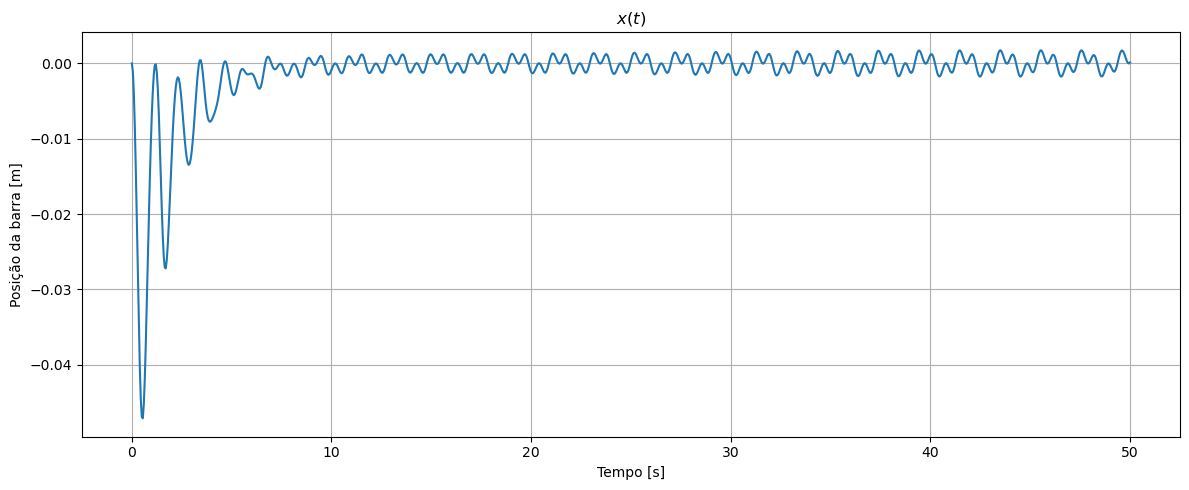

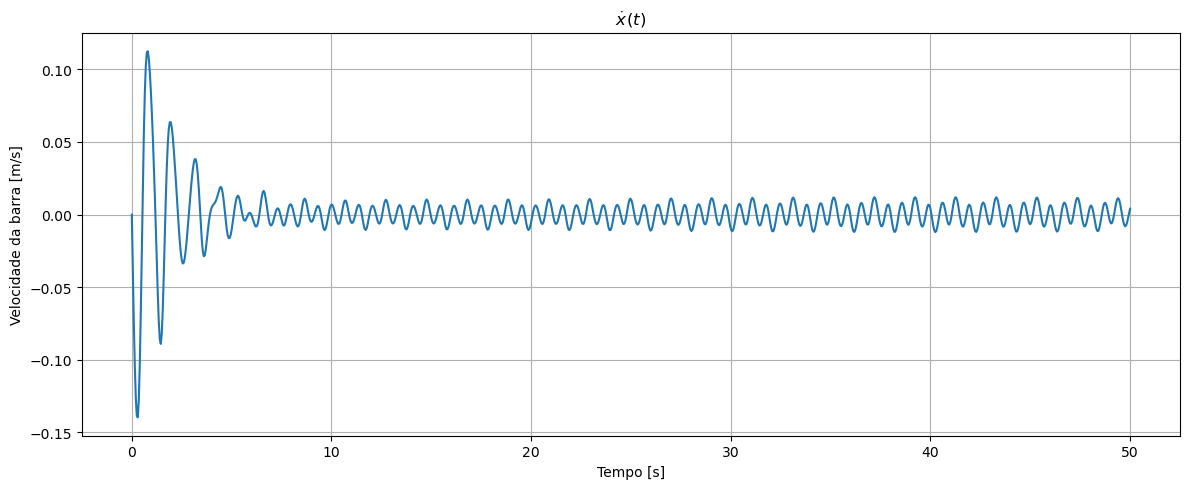

In [37]:
M = 4
m = 0.1
l = 1
mu = 7
g = 9.8
N = 100

#equação da barra para N pendulos

def sistemaN(y, t):                             
    x = y[0] 
    v = y[1]
    theta_N = [y[2*i + 2] for i in range (N)]
    omega_N = [y[2*i + 3] for i in range(N)]

    soma_sencos = 0
    soma_omegasen = 0
    soma_coscos = 0

    #calcula a soma para cada pendulo

    for i in range(N):
        theta = theta_N[i]
        omega = omega_N[i]

        soma_sencos += np.sin(theta) * np.cos(theta)
        soma_omegasen += omega**2 * np.sin(theta)
        soma_coscos += np.cos(theta)**2 
    
    #equação da barra

    dv = (
        -mu*v - m*g*soma_sencos - m*l*soma_omegasen
    ) / (M + N*m - m*soma_coscos)
    
    dx = v
    
    #calcula dtheta para cada pendulo e domega (equção dos pendulos)

    dtheta_N = []
    domega_N = []

    for i in range (N):
        theta = theta_N[i]
        dtheta_N.append(omega_N[i])
        domega_N.append((dv*np.cos(theta) - g*np.sin(theta))/l)

    #retorno da função

    retorna = [dx, dv]

    for i in range(N):
        retorna.append(dtheta_N[i])
        retorna.append(domega_N[i])

    return retorna

theta_N_0 = np.zeros(N)
theta_N_0 = np.random.uniform(-0.5, 0.5, N)     #conjunto aleatório de condições iniciais
#theta_N_0 = np.zeros(N)
#theta_N_0[0] = np.pi/6
omega_N_0 = np.zeros(N)    #velocidades angulares iguais a zero
v0 = 0
x0 = 0

#vetor de condições iniciais 

y0 = [x0, v0]
for i in range(N):
    y0.append(theta_N_0[i])
    y0.append(omega_N_0[i])

t = np.linspace(0, 50, 1000)

sol = odeint(sistemaN, y0, t)

#grafico angulo X tempo

plt.figure(figsize=(12, 5))
amostra = [0, 25, 50, 75, 99]
for i in amostra:
    plt.plot(t, sol[:, 2 + 2*i], label=rf'$\theta_{{{i+1}}}$')

plt.xlabel('Tempo (s)')
plt.ylabel('Ângulo (rad)')
plt.title(r'$\theta$ vs $t$ com 5 amostras')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Ângulo amostras
for i, a in enumerate(amostra):
    angulo = sol[-1, 2 + 2*a]
    print(f"Pêndulo {a+1:3d}: θ = {angulo:.4f} rad")


#grafico velocidades angulares X tempo

plt.figure(figsize=(12, 5))
amostra = [0, 25, 50, 75, 99]
for i in amostra:
    plt.plot(t, sol[:, 3 + 2*i], label=rf'$\dot \theta_{{{i+1}}}$')

plt.xlabel('Tempo [s]')
plt.ylabel('Velocidade [rad\s]')
plt.title(r'$\dot\theta$ vs $t$ com 5 amostras')
plt.legend()
plt.grid(True)
plt.tight_layout()

#grafico posição da barra X tempo

plt.figure(figsize=(12, 5))
plt.plot(t, sol[:, 0])
plt.xlabel('Tempo [s]')
plt.ylabel('Posição da barra [m]')
plt.title(r'$x(t)$')
plt.grid(True)
plt.tight_layout()

print(f"posição final da barra: {sol[-1, 0]}")

#grafico velocidade da barra

plt.figure(figsize=(12, 5))
plt.plot(t, sol[:, 1])
plt.xlabel('Tempo [s]')
plt.ylabel('Velocidade da barra [m/s]')
plt.title(r'$\dot x(t)$')
plt.grid(True)
plt.tight_layout()

print(f"velocidade final da barra: {sol[-1, 1]}")

plt.show()